# Ensemble comparison — low-review classification (Family C)

Mirror of the regression package's `ensemble_comparison.ipynb`. Base models are the tuned Family A
logistic regression and the two Family B models (random forest, CatBoost) from `baseline_variant_review`.
Four combinations are compared on the **validation window** and the chosen one is scored **once** on test:

| Method | What is learned |
|---|---|
| `mean_three` | arithmetic mean of the three probabilities — nothing |
| `mean_rf_cb` | mean of the two tree models — nothing |
| `convex` | non-negative weights summing to one, maximising OOF average precision (simplex grid, step 0.05) |
| `logit_stack` | logistic regression on logit(p) of the three, fitted on OOF rows |

OOF probabilities come from the three label-matured expanding folds (`split.matured_cv`), so the meta-learner
only ever sees predictions made by a base model that had not seen that order and whose training labels were
known at the fold cutoff. Orders before the first cutoff (July 2017) have no OOF prediction and are excluded.

The notebook also carries the two audits the report needs: an empirical **leakage audit** of the feature table
and a **class-balance study** (weighting vs. none vs. resampling vs. calibration). Set `QUICK = True` for a
dry run; the report numbers come from `QUICK = False` after `30` has been run in full.

In [1]:
from pathlib import Path
import sys, warnings
_c = Path.cwd()
ROOT = next((p for p in [_c, *_c.parents, _c / "Phase 2" / "classification", _c / "classification"]
             if (p / "config" / "problem_spec.json").is_file() and (p / "src" / "paths.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the repository root, Phase 2, or Phase 2/classification.")
sys.path.insert(0, str(ROOT / "src"))
import paths  # adds Phase 2/src (regression package) to sys.path as well
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import clf_config as config, clf_features as features, clf_split as split, clf_pipelines as pipelines, clf_evaluate as evaluate
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
ACCENT, GREY, RED = "#2563eb", "#9ca3af", "#dc2626"
for d in (config.FIGURES_DIR, config.RESULTS_DIR, config.PROCESSED_DIR, config.MODELS_DIR): d.mkdir(parents=True, exist_ok=True)
print("package root:", ROOT)
import joblib, json, time
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
import clf_ensembles as ensembles

QUICK = True
PROBLEM = "p2"
SCORING = evaluate.SCORING[PROBLEM]
OUT = config.ROOT / "outputs"
BEST = OUT / "selected_models.json"
print("selected configurations from baseline_variant_review:", BEST.exists())

package root: c:\Users\wanglr\Downloads\scp5006\IT5006-Group9-Olist-Project\Phase 2\classification
selected configurations from baseline_variant_review: True


## 1. Data and protocol

In [2]:
df = features.load_feature_table()
cohort = features.cohort(df, PROBLEM)
S = split.split_frame(cohort)
X_tr, y_tr = split.xy(S["train"], PROBLEM); X_va, y_va = split.xy(S["validation"], PROBLEM); X_te, y_te = split.xy(S["test"], PROBLEM)
CV = split.matured_cv(S["train"], PROBLEM)
display(split.window_summary(cohort, PROBLEM)); split.fold_summary(S["train"], PROBLEM)

,orders,first purchase,last purchase,positive rate,delivered by T share
window,,,,,
train,54372,2016-09-04,2018-02-26,0.1366,0.917
validation,7125,2018-03-01,2018-03-31,0.2261,0.770
test,12655,2018-07-01,2018-08-29,0.1066,0.911
pending_label,3933,2018-01-06,2018-02-28,0.2914,0.699


,fit_rows,score_rows,score_from,score_to
fold,,,,
1,13395,12404,2017-07-01,2017-09-30
2,25366,17487,2017-10-01,2017-12-31
3,42250,9860,2018-01-01,2018-02-26


## 2. Leakage audit

`features.assert_no_leakage` is structural (no post-outcome column can be a feature; the delivery-as-of-T block is
empty for orders not delivered by T). The empirical checks below go further:

* **history** — recomputes seller history from scratch for a sample of orders and confirms that only outcomes
  known before the order's purchase time contributed;
* **at_T** — internal consistency of the delivery-as-of-T block;
* **review_time** — share of reviews written before T. The survey trigger T = min(delivered, estimated) is an
  assumption about Olist's process; reviews dated before T are cases where that assumption does not hold;
* **single_feature_auc** — ranking power of each feature alone on validation. A feature with AUC near 1.0
  would be encoding the label. `delivered_by_T` leading at about 0.77 is the delivery effect that Phase 1
  documented (late orders average 2.57 stars), not leakage: it is known at T by construction.

In [3]:
features.assert_no_leakage(cohort, PROBLEM)
audit = features.leakage_audit(cohort, PROBLEM, sample=800 if QUICK else 3000, full=df)
for k in ("history", "at_T", "review_time"):
    print(f"--- {k}"); print(audit[k].round(4).to_string())
audit["single_feature_auc"].to_csv(OUT / "tables/single_feature_auc.csv", index=False)
display(audit["single_feature_auc"].head(12).round(3))
assert audit["history"]["only outcomes known before purchase"] == 1.0
assert audit["single_feature_auc"].roc_auc.max() < 0.9, "a single feature ranks the label almost perfectly: inspect it"
print("leakage audit passed")

--- history
orders checked                         800.0
seller_prior_orders exact match          1.0
only outcomes known before purchase      1.0
--- at_T
delivery_days_at_T is NaN when not delivered by T    1.0000
days_vs_promise_at_T <= 0 when delivered by T        1.0000
carrier_handover only when carrier date <= T         1.0000
delivered_by_T share                                 0.8914
--- review_time
reviews created before T        0.0290
median days from T to review    0.2836


,feature,roc_auc,pr_auc
0,delivered_by_T,0.772,0.495
1,customer_zip2,0.668,0.372
2,customer_state,0.640,0.330
3,seller_id_enc,0.625,0.341
4,route_prior_mean_delivery_days,0.620,0.308
5,route_prior_late_rate,0.609,0.320
6,total_freight,0.609,0.301
7,max_distance_km,0.594,0.289
8,same_state,0.588,0.263
9,promised_days,0.561,0.250


leakage audit passed


## 3. Base models

Configurations come from `outputs/selected_models.json` (written by `baseline_variant_review`). If that file is
absent the defaults below are used so this notebook runs standalone; the report must cite the tuned versions.

In [4]:
models = pipelines.classification_models(PROBLEM)
base = {k: models[k][0] for k in ("A_linear_tuned", "B_rf", "B_catboost")}
best = json.load(open(BEST))["best_params"] if BEST.exists() else {}
defaults = {"A_linear_tuned": {"model__C": 1.0},
            "B_rf": {"model__n_estimators": 400, "model__max_depth": 16, "model__min_samples_leaf": 20, "model__max_features": 0.4},
            "B_catboost": {"model__iterations": 600, "model__learning_rate": 0.05, "model__depth": 6, "model__l2_leaf_reg": 5.0}}
for name, pipe in base.items():
    params = {k: v for k, v in best.get(name, defaults[name]).items()}
    if QUICK:
        params.update({"B_rf": {"model__n_estimators": 100}, "B_catboost": {"model__iterations": 150}}.get(name, {}))
    pipe.set_params(**params)
    print(name, {k.replace("model__", ""): (round(v, 4) if isinstance(v, float) else v) for k, v in params.items()})

A_linear_tuned {'C': 0.01}
B_rf {'max_depth': 22, 'max_features': 0.2586, 'min_samples_leaf': 100, 'n_estimators': 100}
B_catboost {'depth': 4, 'iterations': 150, 'l2_leaf_reg': 1.6378, 'learning_rate': 0.0202, 'one_hot_max_size': 10, 'random_strength': 0.6196, 'subsample': 0.6969}


## 4. Out-of-fold probabilities and full-train fits

OOF rows are the scored rows of the three matured folds (purchased July 2017 to February 2018); the warm-up
before July 2017 has no OOF prediction. Base models are then refitted on the whole training window to produce
validation and test probabilities.

In [5]:
t0 = time.time()
oof = ensembles.oof_probabilities(base, X_tr, y_tr, CV)
y_oof = y_tr.iloc[oof.index]
print(f"OOF rows: {len(oof)} of {len(X_tr)} training rows ({time.time()-t0:.0f}s); positive rate {y_oof.mean():.3f}")
fitted = {name: clone(pipe).fit(X_tr, y_tr) for name, pipe in base.items()}
P_va = pd.DataFrame({n: m.predict_proba(X_va)[:, 1] for n, m in fitted.items()})
P_te = pd.DataFrame({n: m.predict_proba(X_te)[:, 1] for n, m in fitted.items()})
print(f"all fits done ({time.time()-t0:.0f}s)")
oof.corr().round(3)

OOF rows: 39751 of 54372 training rows (41s); positive rate 0.137
all fits done (61s)


,A_linear_tuned,B_rf,B_catboost
A_linear_tuned,1.000,0.945,0.952
B_rf,0.945,1.000,0.971
B_catboost,0.952,0.971,1.000


## 5. Ensembles on validation, selection rule, frozen thresholds

Selection: highest validation PR-AUC; an ensemble is retained only if it beats the best **single** model by at
least 1% relative (same rule as the stacking decision in baseline_variant_review). Thresholds maximise F1 on validation and
are then frozen.

In [6]:
w_convex = ensembles.convex_weights(oof, y_oof)
meta = ensembles.fit_logit_stack(oof, y_oof)
weights = pd.DataFrame({"convex_weight": w_convex, "logit_stack_coef": meta.coef_[0]}, index=oof.columns)
weights.to_csv(OUT / "tables/ensemble_weights.csv"); display(weights.round(3))

def combos(P):
    return {"mean_three": ensembles.mean_proba(P),
            "mean_rf_cb": ensembles.mean_proba(P[["B_rf", "B_catboost"]]),
            "convex": ensembles.weighted_proba(P, w_convex),
            "logit_stack": ensembles.predict_stack(meta, P)}
val_proba = {**{n: P_va[n].values for n in P_va}, **combos(P_va)}
test_proba = {**{n: P_te[n].values for n in P_te}, **combos(P_te)}
thresholds = {n: evaluate.best_threshold(y_va, p) for n, p in val_proba.items()}
val_tbl = pd.DataFrame({n: evaluate.classification_metrics(y_va, p, thresholds[n]) for n, p in val_proba.items()}).T
best_single = val_tbl.loc[list(base), "pr_auc"].idxmax()
best_ens = val_tbl.loc[list(combos(P_va)), "pr_auc"].idxmax()
keep = val_tbl.loc[best_ens, "pr_auc"] >= 1.01 * val_tbl.loc[best_single, "pr_auc"]
FINAL = best_ens if keep else best_single
print(f"best single {best_single} {val_tbl.loc[best_single,'pr_auc']:.4f} | best ensemble {best_ens} {val_tbl.loc[best_ens,'pr_auc']:.4f} -> "
      f"{'ensemble retained' if keep else 'ensemble NOT retained'}; FINAL = {FINAL}")
val_tbl[["pr_auc", "roc_auc", "precision", "recall", "f1", "brier", "threshold"]].round(3)

,convex_weight,logit_stack_coef
A_linear_tuned,0.2,0.600
B_rf,0.6,0.357
B_catboost,0.2,0.142


best single B_rf 0.6418 | best ensemble convex 0.6346 -> ensemble NOT retained; FINAL = B_rf


,pr_auc,roc_auc,precision,recall,f1,brier,threshold
A_linear_tuned,0.602,0.841,0.626,0.709,0.665,0.193,0.753
B_rf,0.642,0.845,0.613,0.719,0.662,0.177,0.626
B_catboost,0.595,0.838,0.631,0.700,0.663,0.196,0.666
mean_three,0.623,0.844,0.630,0.705,0.665,0.187,0.686
mean_rf_cb,0.634,0.845,0.619,0.716,0.664,0.185,0.632
convex,0.635,0.845,0.631,0.701,0.664,0.183,0.678
logit_stack,0.616,0.844,0.632,0.706,0.667,0.117,0.319


## 6. Test window, scored once

Every row is scored on the same test orders at its frozen threshold. The PR-AUC column is cross-checked with
an independent implementation of average precision (sum over thresholds of ΔRecall × Precision) so the
sklearn figures in Table 7 can be trusted.

In [7]:
def manual_average_precision(y, p):
    order = np.argsort(-p, kind="mergesort"); y = np.asarray(y)[order]
    tp = np.cumsum(y); fp = np.cumsum(1 - y)
    precision = tp / (tp + fp); recall = tp / y.sum()
    # step-wise AP, evaluated at each distinct score (ties collapsed)
    p_sorted = p[order]; last = np.r_[p_sorted[1:] != p_sorted[:-1], True]
    precision, recall = precision[last], recall[last]
    return float(np.sum(np.diff(np.r_[0.0, recall]) * precision))

test_tbl = pd.DataFrame({n: evaluate.classification_metrics(y_te, p, thresholds[n]) for n, p in test_proba.items()}).T
test_tbl["pr_auc_manual"] = [manual_average_precision(y_te.values, p) for p in test_proba.values()]
assert np.allclose(test_tbl.pr_auc, test_tbl.pr_auc_manual, atol=1e-6), "PR-AUC cross-check failed"
test_tbl["val_pr_auc"] = val_tbl.pr_auc
cols = ["val_pr_auc", "pr_auc", "roc_auc", "precision", "recall", "f1", "balanced_acc", "brier", "recall_top10", "flag_rate", "threshold"]
test_tbl[cols].round(3).to_csv(OUT / "tables/ensemble_test_results.csv")
print("PR-AUC cross-check passed (sklearn == manual)")
test_tbl[cols].round(3)

PR-AUC cross-check passed (sklearn == manual)


,val_pr_auc,pr_auc,roc_auc,precision,recall,f1,balanced_acc,brier,recall_top10,flag_rate,threshold
A_linear_tuned,0.602,0.358,0.735,0.399,0.402,0.400,0.665,0.159,0.380,0.107,0.753
B_rf,0.642,0.353,0.731,0.378,0.419,0.398,0.668,0.158,0.372,0.118,0.626
B_catboost,0.595,0.345,0.729,0.397,0.405,0.401,0.666,0.184,0.377,0.109,0.666
mean_three,0.623,0.364,0.736,0.400,0.406,0.403,0.667,0.165,0.373,0.108,0.686
mean_rf_cb,0.634,0.360,0.733,0.385,0.414,0.399,0.667,0.169,0.372,0.115,0.632
convex,0.635,0.365,0.735,0.399,0.404,0.402,0.666,0.162,0.368,0.108,0.678
logit_stack,0.616,0.366,0.737,0.397,0.400,0.399,0.664,0.086,0.374,0.107,0.319


## 7. Class-balance study

The 13.7% positive rate is handled with class weights in baseline_variant_review. This cell asks whether that choice matters,
using the random forest (fast to refit): no weighting, `balanced_subsample`, SMOTE (if `imbalanced-learn` is
installed), and `balanced_subsample` followed by isotonic calibration fitted on validation.

What to expect: weighting changes the probability scale (Brier, flag rate at 0.5) far more than the ranking
(PR-AUC); the tuned threshold does most of the work; calibration restores interpretable probabilities. Note the
calibrated row's validation metrics are in-sample for the calibrator; read its test columns.

In [8]:
from sklearn.ensemble import RandomForestClassifier
rf_params = {k.replace("model__", ""): v for k, v in base["B_rf"].get_params().items()
             if k.startswith("model__") and k.count("__") == 1
             and k not in ("model__class_weight", "model__random_state", "model__n_jobs")}
variants = {"rf_no_weighting": None, "rf_balanced_subsample": "balanced_subsample"}
rows, probs = [], {}
for name, cw in variants.items():
    pipe = clone(base["B_rf"]).set_params(model__class_weight=cw).fit(X_tr, y_tr)
    probs[name] = (pipe.predict_proba(X_va)[:, 1], pipe.predict_proba(X_te)[:, 1])
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    pipe = ImbPipeline([("pre", pipelines.make_preprocessor("tree", PROBLEM)), ("smote", SMOTE(random_state=config.RANDOM_STATE)),
                        ("model", RandomForestClassifier(random_state=config.RANDOM_STATE, n_jobs=-1, **rf_params))]).fit(X_tr, y_tr)
    probs["rf_smote"] = (pipe.predict_proba(X_va)[:, 1], pipe.predict_proba(X_te)[:, 1])
except ImportError:
    print("imbalanced-learn not installed: SMOTE row skipped")
iso = IsotonicRegression(out_of_bounds="clip").fit(probs["rf_balanced_subsample"][0], y_va)
probs["rf_balanced_calibrated"] = tuple(iso.predict(p) for p in probs["rf_balanced_subsample"])
for name, (pv, pt) in probs.items():
    thr = evaluate.best_threshold(y_va, pv)
    mv, mt = evaluate.classification_metrics(y_va, pv, thr), evaluate.classification_metrics(y_te, pt, thr)
    at_half = evaluate.classification_metrics(y_te, pt, 0.5)
    rows.append({"variant": name, "val_pr_auc": mv["pr_auc"], "test_pr_auc": mt["pr_auc"], "test_roc_auc": mt["roc_auc"],
                 "test_brier": mt["brier"], "tuned_threshold": thr, "test_recall@tuned": mt["recall"], "test_precision@tuned": mt["precision"],
                 "flag_rate@0.5": at_half["flag_rate"], "recall@0.5": at_half["recall"]})
balance = pd.DataFrame(rows).set_index("variant"); balance.to_csv(OUT / "tables/class_balance_study.csv")
balance.round(3)

,val_pr_auc,test_pr_auc,test_roc_auc,test_brier,tuned_threshold,test_recall@tuned,test_precision@tuned,flag_rate@0.5,recall@0.5
variant,,,,,,,,,
rf_no_weighting,0.643,0.355,0.730,0.086,0.262,0.409,0.384,0.079,0.309
rf_balanced_subsample,0.642,0.353,0.731,0.158,0.626,0.419,0.378,0.166,0.482
rf_smote,0.627,0.352,0.725,0.102,0.443,0.406,0.386,0.104,0.389
rf_balanced_calibrated,0.636,0.335,0.729,0.088,0.333,0.419,0.378,0.103,0.382


## 8. Figures

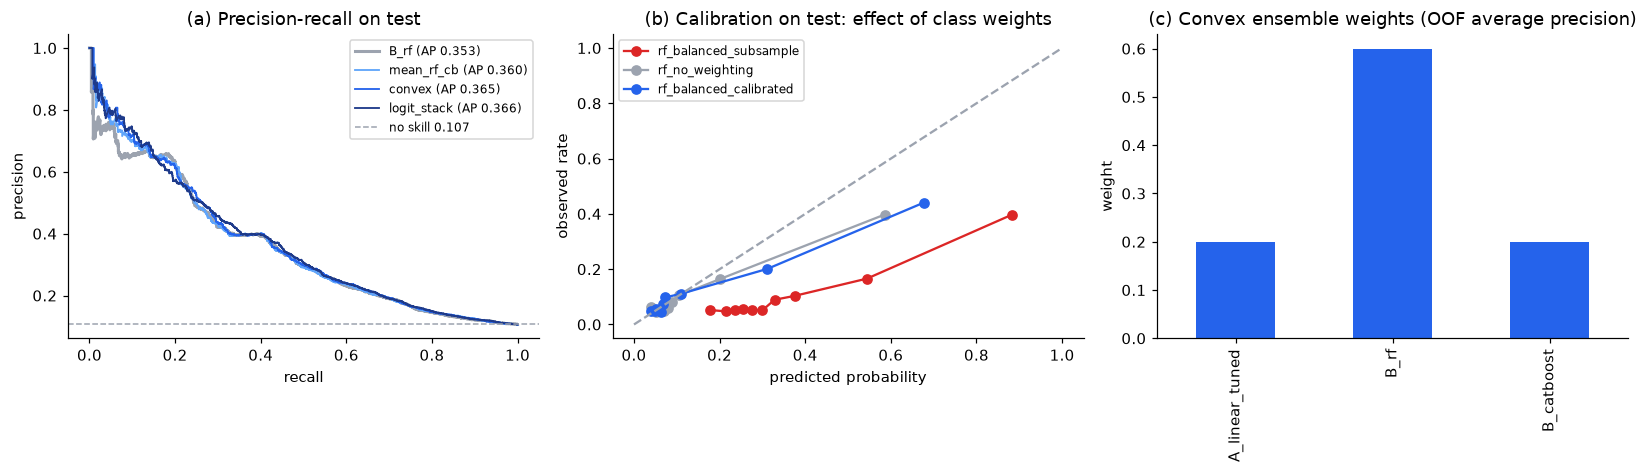

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
show = [best_single, "mean_rf_cb", "convex", "logit_stack"]
pal = dict(zip(show, [GREY, "#60a5fa", ACCENT, "#1e3a8a"]))
for n in show:
    pr, rc, _ = precision_recall_curve(y_te, test_proba[n])
    ax[0].plot(rc, pr, color=pal[n], lw=2 if n == FINAL else 1.2, label=f"{n} (AP {test_tbl.loc[n,'pr_auc']:.3f})")
ax[0].axhline(y_te.mean(), ls="--", color=GREY, lw=1, label=f"no skill {y_te.mean():.3f}")
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision"); ax[0].set_title("(a) Precision-recall on test"); ax[0].legend(fontsize=8)
for n, c in (("rf_balanced_subsample", RED), ("rf_no_weighting", GREY), ("rf_balanced_calibrated", ACCENT)):
    if n in probs:
        f, m = calibration_curve(y_te, probs[n][1], n_bins=10, strategy="quantile"); ax[1].plot(m, f, marker="o", color=c, label=n)
ax[1].plot([0, 1], [0, 1], ls="--", color=GREY); ax[1].set_xlabel("predicted probability"); ax[1].set_ylabel("observed rate")
ax[1].set_title("(b) Calibration on test: effect of class weights"); ax[1].legend(fontsize=8)
weights.convex_weight.plot.bar(ax=ax[2], color=ACCENT); ax[2].set_title("(c) Convex ensemble weights (OOF average precision)"); ax[2].set_ylabel("weight")
plt.tight_layout(); fig.savefig(OUT / "figures/04_ensemble_comparison.png", bbox_inches="tight")

## 9. Save

In [10]:
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
summary = {"final": FINAL, "ensemble_retained": bool(keep), "best_single": best_single, "best_ensemble": best_ens,
           "thresholds": thresholds, "convex_weights": dict(zip(oof.columns, map(float, w_convex))),
           "oof_rows": int(len(oof)), "quick_mode": QUICK, "val_pr_auc": val_tbl.pr_auc.round(4).to_dict(),
           "test_pr_auc": test_tbl.pr_auc.round(4).to_dict()}
json.dump(summary, open(OUT / "ensemble_summary.json", "w"), indent=2, default=str)
(OUT / "oof").mkdir(exist_ok=True)
oof.assign(is_low_review=y_oof.values, order_id=S["train"].order_id.iloc[oof.index].values).to_csv(OUT / "oof/base_oof_probabilities.csv", index=False)
joblib.dump({"base": fitted, "method": FINAL, "convex_weights": w_convex, "meta": meta, "threshold": thresholds[FINAL],
             "features": list(X_tr.columns), "problem": PROBLEM}, config.MODELS_DIR / "ensemble_bundle.joblib")
print(json.dumps({k: summary[k] for k in ("final", "ensemble_retained", "best_single", "best_ensemble", "oof_rows")}, indent=2))

{
  "final": "B_rf",
  "ensemble_retained": false,
  "best_single": "B_rf",
  "best_ensemble": "convex",
  "oof_rows": 39751
}


## 10. Areas that need attention

Read these against the tables above before quoting any number in the report.

1. **Validation is the hardest month.** March 2018 has a 22.6% positive rate against 13.7% in training and
   10.7% in test, so validation PR-AUC is higher than test PR-AUC for every model (PR-AUC scales with the
   positive rate) and thresholds chosen on validation flag fewer orders on test than intended. Report both
   rates next to the metrics, and consider the `min_recall` threshold rule in `evaluate.best_threshold` if the
   CX team needs a guaranteed recall.
2. **Class weights distort probabilities, not rankings.** The balance study shows near-identical PR-AUC across
   weighting choices but very different Brier scores and flag rates at 0.5. If the risk score is shown to the CX
   team as a probability, use the calibrated variant; if it is only used to rank, weighting is harmless.
3. **The ensemble gain is small by construction.** The three base models rank the same orders similarly (see
   the OOF correlation matrix), so averaging mostly reduces variance. Keep the retention rule honest: if the
   best ensemble is not at least 1% better on validation, the report says so and keeps the single model.
4. **Survey-trigger assumption.** About 3% of reviews are dated before T. These orders' delivery-as-of-T
   features describe information that arrived after the customer wrote the review; the share is small but it
   belongs in Limitations.
5. **OOF warm-up.** Orders before July 2017 have no OOF prediction, so the meta-learners are fitted on
   roughly three quarters of the training window. This is stated, not hidden; it mirrors the regression
   development's warm-up exclusion.
6. **Validation and test can disagree on the ensemble.** In the dry run every combination beat the single
   forest on test PR-AUC (0.363-0.370 vs 0.359) but none did on March validation, so the rule kept the single
   model. March is one month with an unusual positive rate; the OOF rows (eight months, about 40k orders) are a
   larger and more representative selection set. If the team prefers, change the retention rule to "better on
   OOF *and* not worse on validation" - but decide that before reading the full-run test numbers, and record
   the decision in docs/phase2_integration.md.
7. **Run `baseline_variant_review` in full before this notebook.** Base configurations are read from
   `outputs/selected_models.json`; the defaults here are placeholders, and a QUICK run writes QUICK parameters
   into that file.